### Import Libraries

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

### Data Importation

In [36]:
df=pd.read_csv('ncr_aqi.csv', parse_dates=['date'])
df.sample(8)

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
81393,2022-06-03 12:00:00,2022-06-03,2022,6,3,12,Friday,0,monsoon,Noida,...,17.3,4.0,0.70,32.6,43.4,67,14.7,9.4,82,Satisfactory
76774,2022-04-14 18:00:00,2022-04-14,2022,4,14,18,Thursday,0,summer,Delhi,...,46.1,5.8,2.11,31.0,31.5,32,18.6,4.2,215,Poor
156590,2024-08-29 18:00:00,2024-08-29,2024,8,29,18,Thursday,0,monsoon,Delhi,...,14.2,4.0,0.57,19.1,30.8,91,16.0,12.9,46,Good
86268,2022-07-26 06:00:00,2022-07-26,2022,7,26,6,Tuesday,0,monsoon,Noida,...,15.4,4.0,0.67,23.8,26.4,100,8.4,9.4,62,Satisfactory
48478,2021-06-10 18:00:00,2021-06-10,2021,6,10,18,Thursday,0,monsoon,Ghaziabad,...,45.8,4.7,1.78,18.3,39.2,68,16.3,5.6,176,Moderate
16841,2020-07-02 12:00:00,2020-07-02,2020,7,2,12,Thursday,0,monsoon,Delhi,...,10.8,4.0,0.35,29.2,37.4,88,14.4,12.3,46,Good
31771,2020-12-11 23:00:00,2020-12-11,2020,12,11,23,Friday,0,winter,Delhi,...,116.4,25.5,4.74,13.1,14.7,63,5.9,0.6,500,Severe
71493,2022-02-16 12:00:00,2022-02-16,2022,2,16,12,Wednesday,0,winter,Delhi,...,66.2,24.7,3.47,21.5,21.0,59,8.5,1.0,402,Severe


In [38]:
df.shape

(201664, 25)

In [40]:
df.columns

Index(['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi', 'aqi_category'],
      dtype='object')

In [42]:
df.set_index('datetime')

,date,year,month,day,hour,day_of_week,is_weekend,season,city,station,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,"Anand Vihar, Delhi",...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,"Jahangirpuri, Delhi",...,138.4,41.5,7.56,15.4,6.8,100,2.8,0.4,500,Severe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31 23:00:00,2025-12-31,2025,12,31,23,Wednesday,0,winter,Ghaziabad,Ghaziabad Vasundhara,...,97.0,23.9,5.58,14.8,16.1,51,3.8,0.9,500,Severe
2025-12-31 06:00:00,2025-12-31,2025,12,31,6,Wednesday,0,winter,Ghaziabad,Ghaziabad Loni,...,119.2,26.9,5.34,12.1,9.8,95,3.2,1.2,500,Severe
2025-12-31 12:00:00,2025-12-31,2025,12,31,12,Wednesday,0,winter,Ghaziabad,Ghaziabad Loni,...,90.3,33.7,3.73,28.2,21.4,57,7.1,2.9,500,Severe


In [44]:
df.isna().sum()

datetime        0
date            0
year            0
month           0
day             0
hour            0
day_of_week     0
is_weekend      0
season          0
city            0
station         0
latitude        0
longitude       0
pm25            0
pm10            0
no2             0
so2             0
co              0
o3              0
temperature     0
humidity        0
wind_speed      0
visibility      0
aqi             0
aqi_category    0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [48]:
numeric_columns=df.select_dtypes(['float64','int64']).columns
numeric_columns

Index(['year', 'month', 'day', 'hour', 'is_weekend', 'latitude', 'longitude',
       'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity',
       'wind_speed', 'visibility', 'aqi'],
      dtype='object')

In [50]:
df.describe()

,date,year,month,day,hour,is_weekend,latitude,longitude,pm25,pm10,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi
count,201664,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000,201664.000000
mean,2022-12-31 12:00:00.000000512,2022.499544,6.521898,15.732664,14.750000,0.285584,28.596791,77.208600,183.420341,348.567402,69.761495,16.028998,3.033964,27.185762,26.895227,61.041564,10.528524,5.007801,265.830148
min,2020-01-01 00:00:00,2020.000000,1.000000,1.000000,6.000000,0.000000,28.372200,77.026600,15.000000,24.000000,8.000000,4.000000,0.300000,12.000000,6.000000,20.000000,2.100000,0.200000,25.000000
25%,2021-07-01 18:00:00,2021.000000,4.000000,8.000000,10.500000,0.000000,28.530800,77.071200,55.300000,104.100000,19.900000,4.500000,0.870000,18.000000,19.900000,39.000000,5.900000,1.900000,103.000000
50%,2022-12-31 12:00:00,2022.500000,7.000000,16.000000,15.000000,0.000000,28.624600,77.201000,99.500000,189.800000,38.300000,8.700000,1.690000,23.300000,27.600000,58.000000,9.200000,4.400000,232.000000
75%,2024-07-01 06:00:00,2024.000000,10.000000,23.000000,19.250000,1.000000,28.668300,77.316400,254.700000,481.200000,94.000000,20.900000,4.120000,31.800000,33.500000,83.000000,14.200000,7.100000,464.000000
max,2025-12-31 00:00:00,2025.000000,12.000000,31.000000,23.000000,1.000000,28.776200,77.504000,900.000000,1979.700000,593.500000,121.600000,22.670000,84.000000,44.800000,100.000000,31.500000,15.000000,500.000000
std,NaN,1.708185,3.448995,8.801392,6.378691,0.451693,0.112215,0.125113,193.138161,370.016790,75.972086,17.201027,3.284094,13.569802,8.984843,24.737106,6.045043,3.685609,171.508950


### Outlier Detection

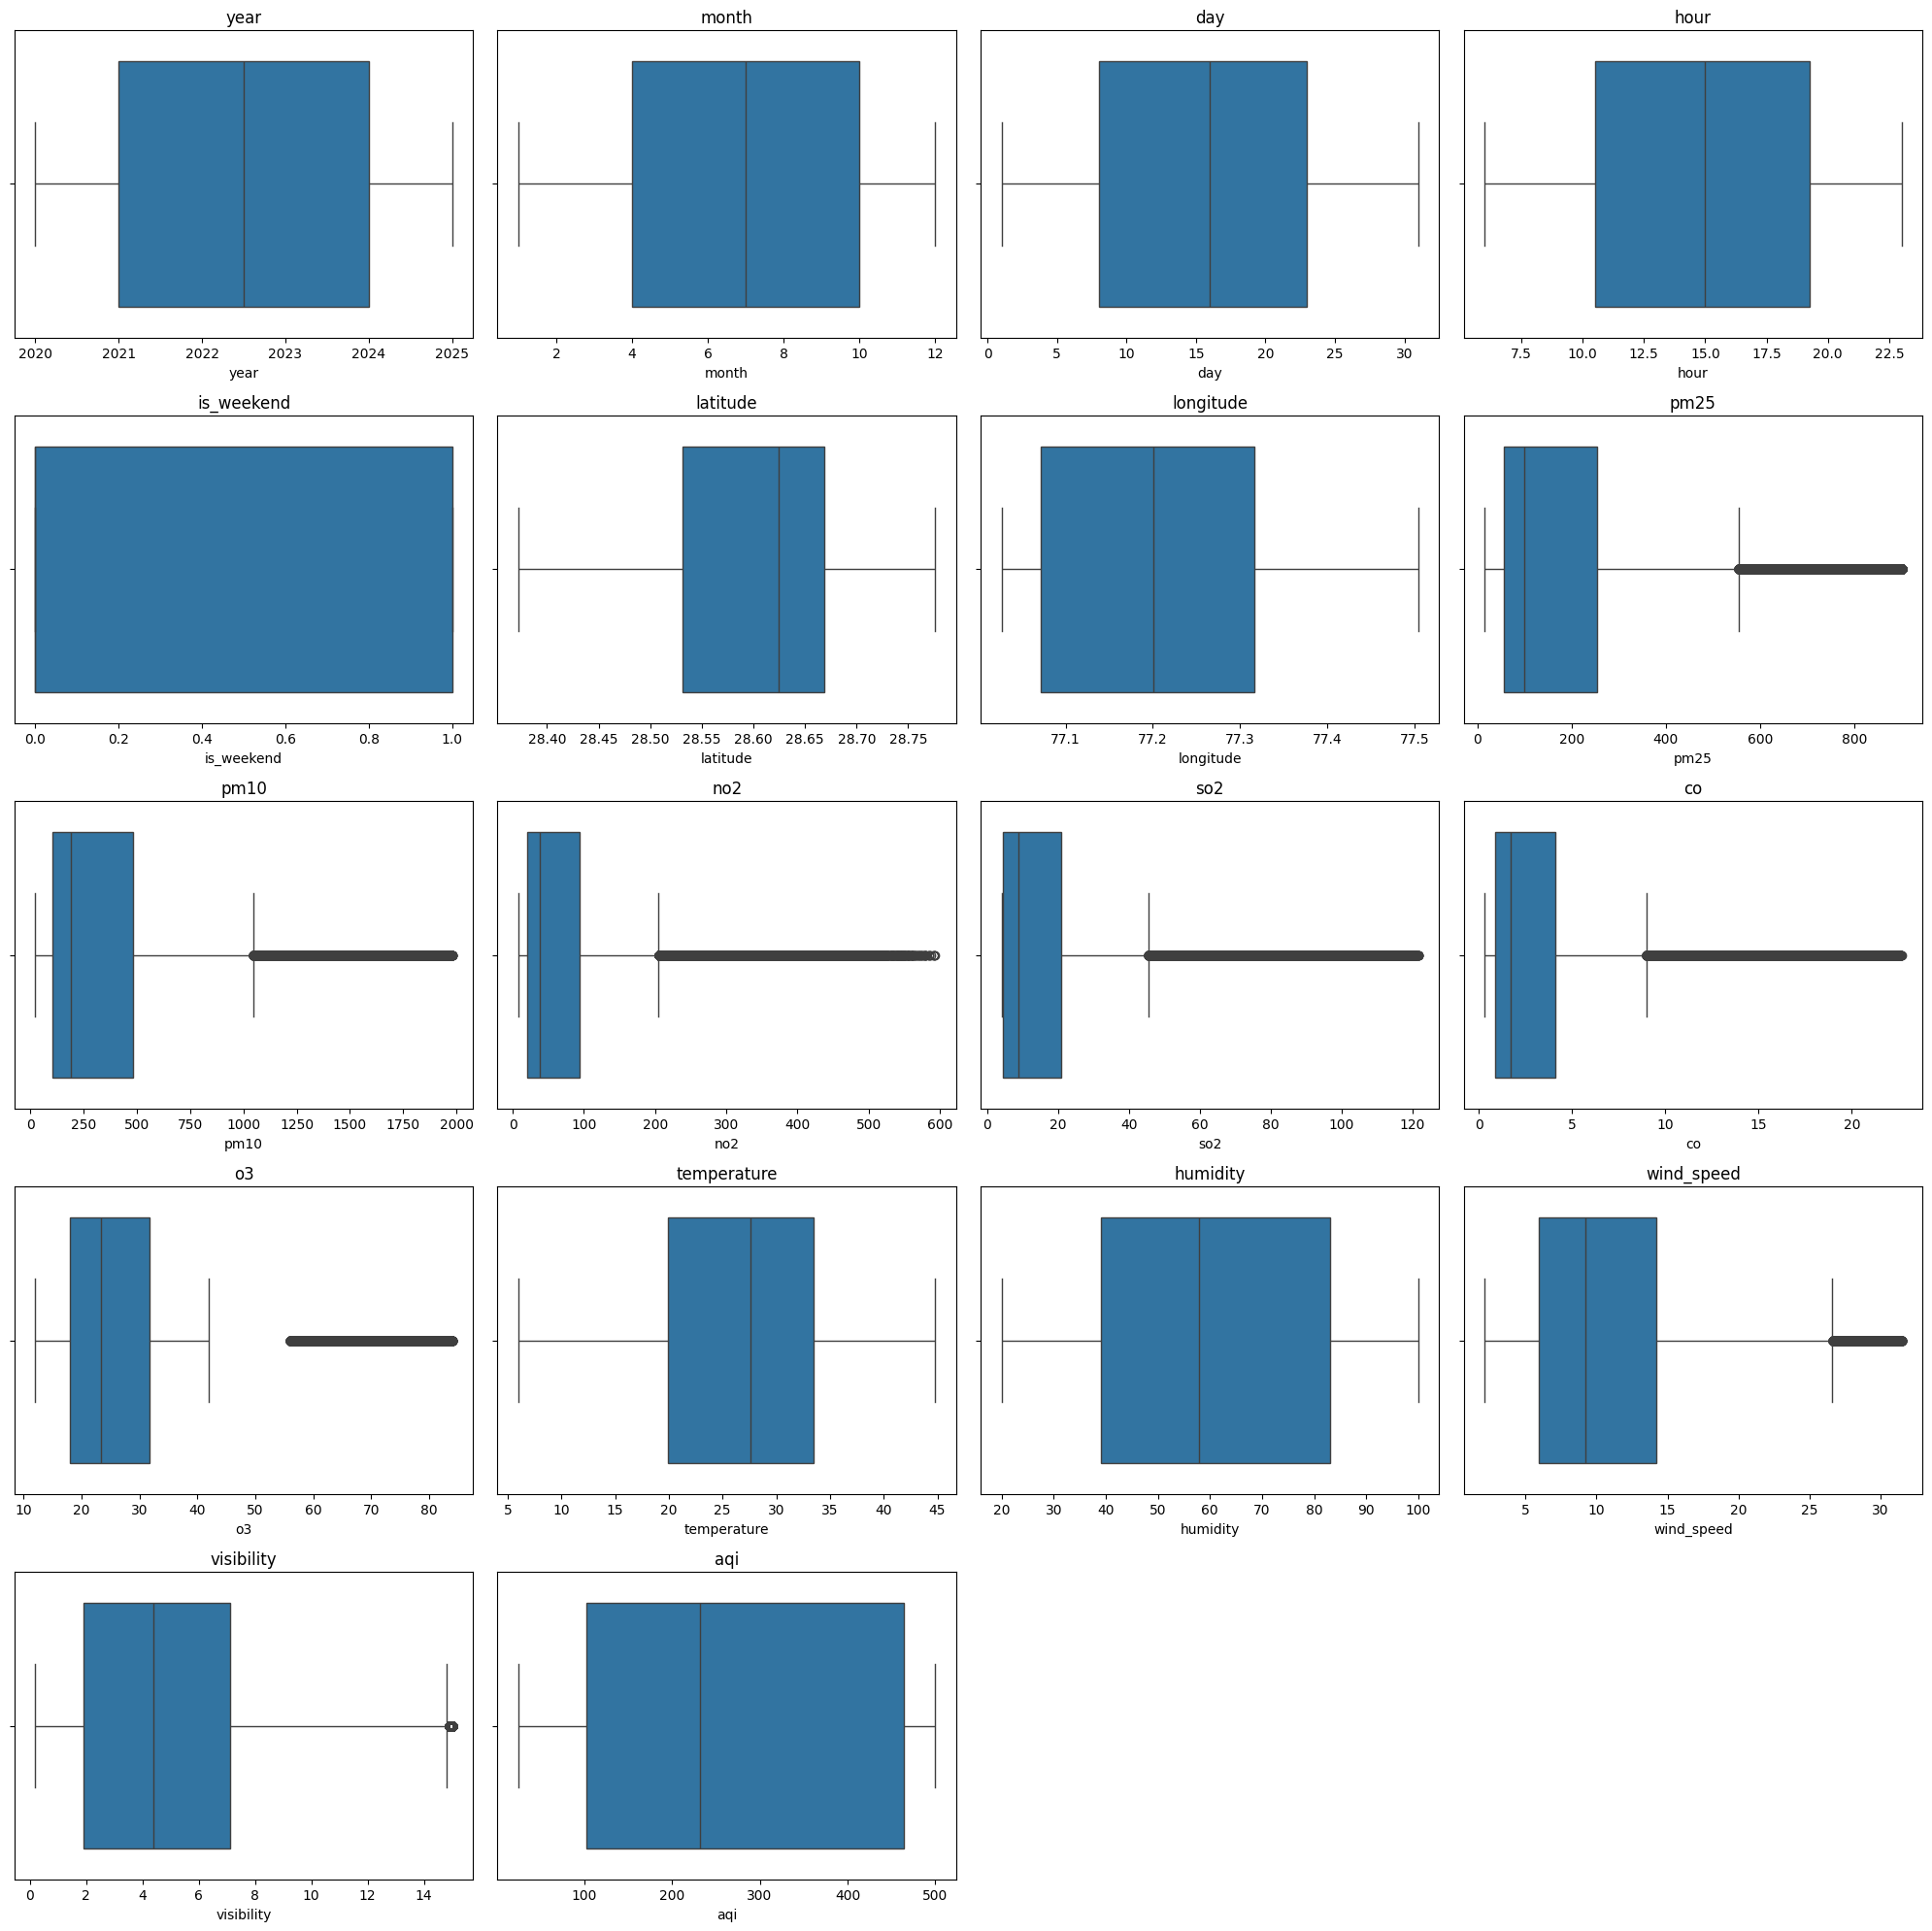

In [52]:
num_cols = len(numeric_columns)  # 20 in your case
cols_per_row = 4                  # 4 plots per row
rows = math.ceil(num_cols / cols_per_row)  # auto-calculate rows

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 4*rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any extra empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


### Date Time Conversion

In [54]:
df['datetime'] = pd.to_datetime(df['datetime'])
type(df['datetime'][0])

pandas._libs.tslibs.timestamps.Timestamp

In [56]:
type(df['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

### Grouping rows as per station and datatime

In [58]:
df = df.sort_values(['station','datetime'])
df.head(10)

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,47.7,5.19,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.3,4.32,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.3,7.13,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.3,4.90,13.2,14.4,48,5.8,1.4,500,Severe
92,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,Thursday,0,winter,Delhi,...,134.8,39.9,7.62,15.1,10.0,98,3.3,0.5,500,Severe
93,2020-01-02 12:00:00,2020-01-02,2020,1,2,12,Thursday,0,winter,Delhi,...,104.9,24.1,4.49,15.6,17.8,62,9.7,1.2,500,Severe
94,2020-01-02 18:00:00,2020-01-02,2020,1,2,18,Thursday,0,winter,Delhi,...,136.0,21.9,5.03,28.6,14.5,59,6.7,1.1,500,Severe
95,2020-01-02 23:00:00,2020-01-02,2020,1,2,23,Thursday,0,winter,Delhi,...,106.6,30.5,4.56,16.8,13.6,60,5.0,0.9,500,Severe
184,2020-01-03 06:00:00,2020-01-03,2020,1,3,6,Friday,0,winter,Delhi,...,122.7,45.9,4.76,13.5,7.1,100,3.5,1.4,500,Severe
185,2020-01-03 12:00:00,2020-01-03,2020,1,3,12,Friday,0,winter,Delhi,...,125.1,40.8,3.75,16.0,18.5,56,9.2,0.9,500,Severe


In [60]:
df['pm25'].quantile([0.25,0.75])

0.25     55.3
0.75    254.7
Name: pm25, dtype: float64

In [62]:
def get_iqr_bounds(col):
    Q1,Q3=col.quantile([0.25,0.75])
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR
    return LB, UB
    

In [64]:
df['pm25'].quantile(0.9)

np.float64(398.8)

In [66]:
lst1 = ['pm25', 'pm10', 'no2','so2', 'co', 'o3', 'wind_speed', 'visibility'] 

for i in lst1:
    LB, UB = get_iqr_bounds(df[i])
    print(f"For feature {i}")
    print(f"Lower Bound: {LB}")
    print(f"Upper Bound: {UB}")
    values = (df[i]> UB).sum()
    print(values)

For feature pm25
Lower Bound: -243.79999999999995
Upper Bound: 553.8
12877
For feature pm10
Lower Bound: -461.55000000000007
Upper Bound: 1046.8500000000001
12980
For feature no2
Lower Bound: -91.25
Upper Bound: 205.14999999999998
13163
For feature so2
Lower Bound: -20.099999999999998
Upper Bound: 45.5
13776
For feature co
Lower Bound: -4.005
Upper Bound: 8.995000000000001
12961
For feature o3
Lower Bound: -2.700000000000003
Upper Bound: 52.5
12696
For feature wind_speed
Lower Bound: -6.549999999999999
Upper Bound: 26.65
3911
For feature visibility
Lower Bound: -5.899999999999999
Upper Bound: 14.899999999999999
685


### Interpolation (done for time series data for computing outliers)

In [68]:
for i in lst1:
    LB, UB = get_iqr_bounds(df[i])
    df[i] = df[i].where((df[i] >= LB) & (df[i] <= UB), other=np.nan)

df[lst1] = (
    df.groupby('station')[lst1]
    .transform(lambda x: x.interpolate(method='linear'))
)

df[lst1] = df[lst1].fillna(method='ffill').fillna(method='bfill')

C:\Users\aashi\AppData\Local\Temp\ipykernel_21488\1390690828.py:10: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[lst1] = df[lst1].fillna(method='ffill').fillna(method='bfill')


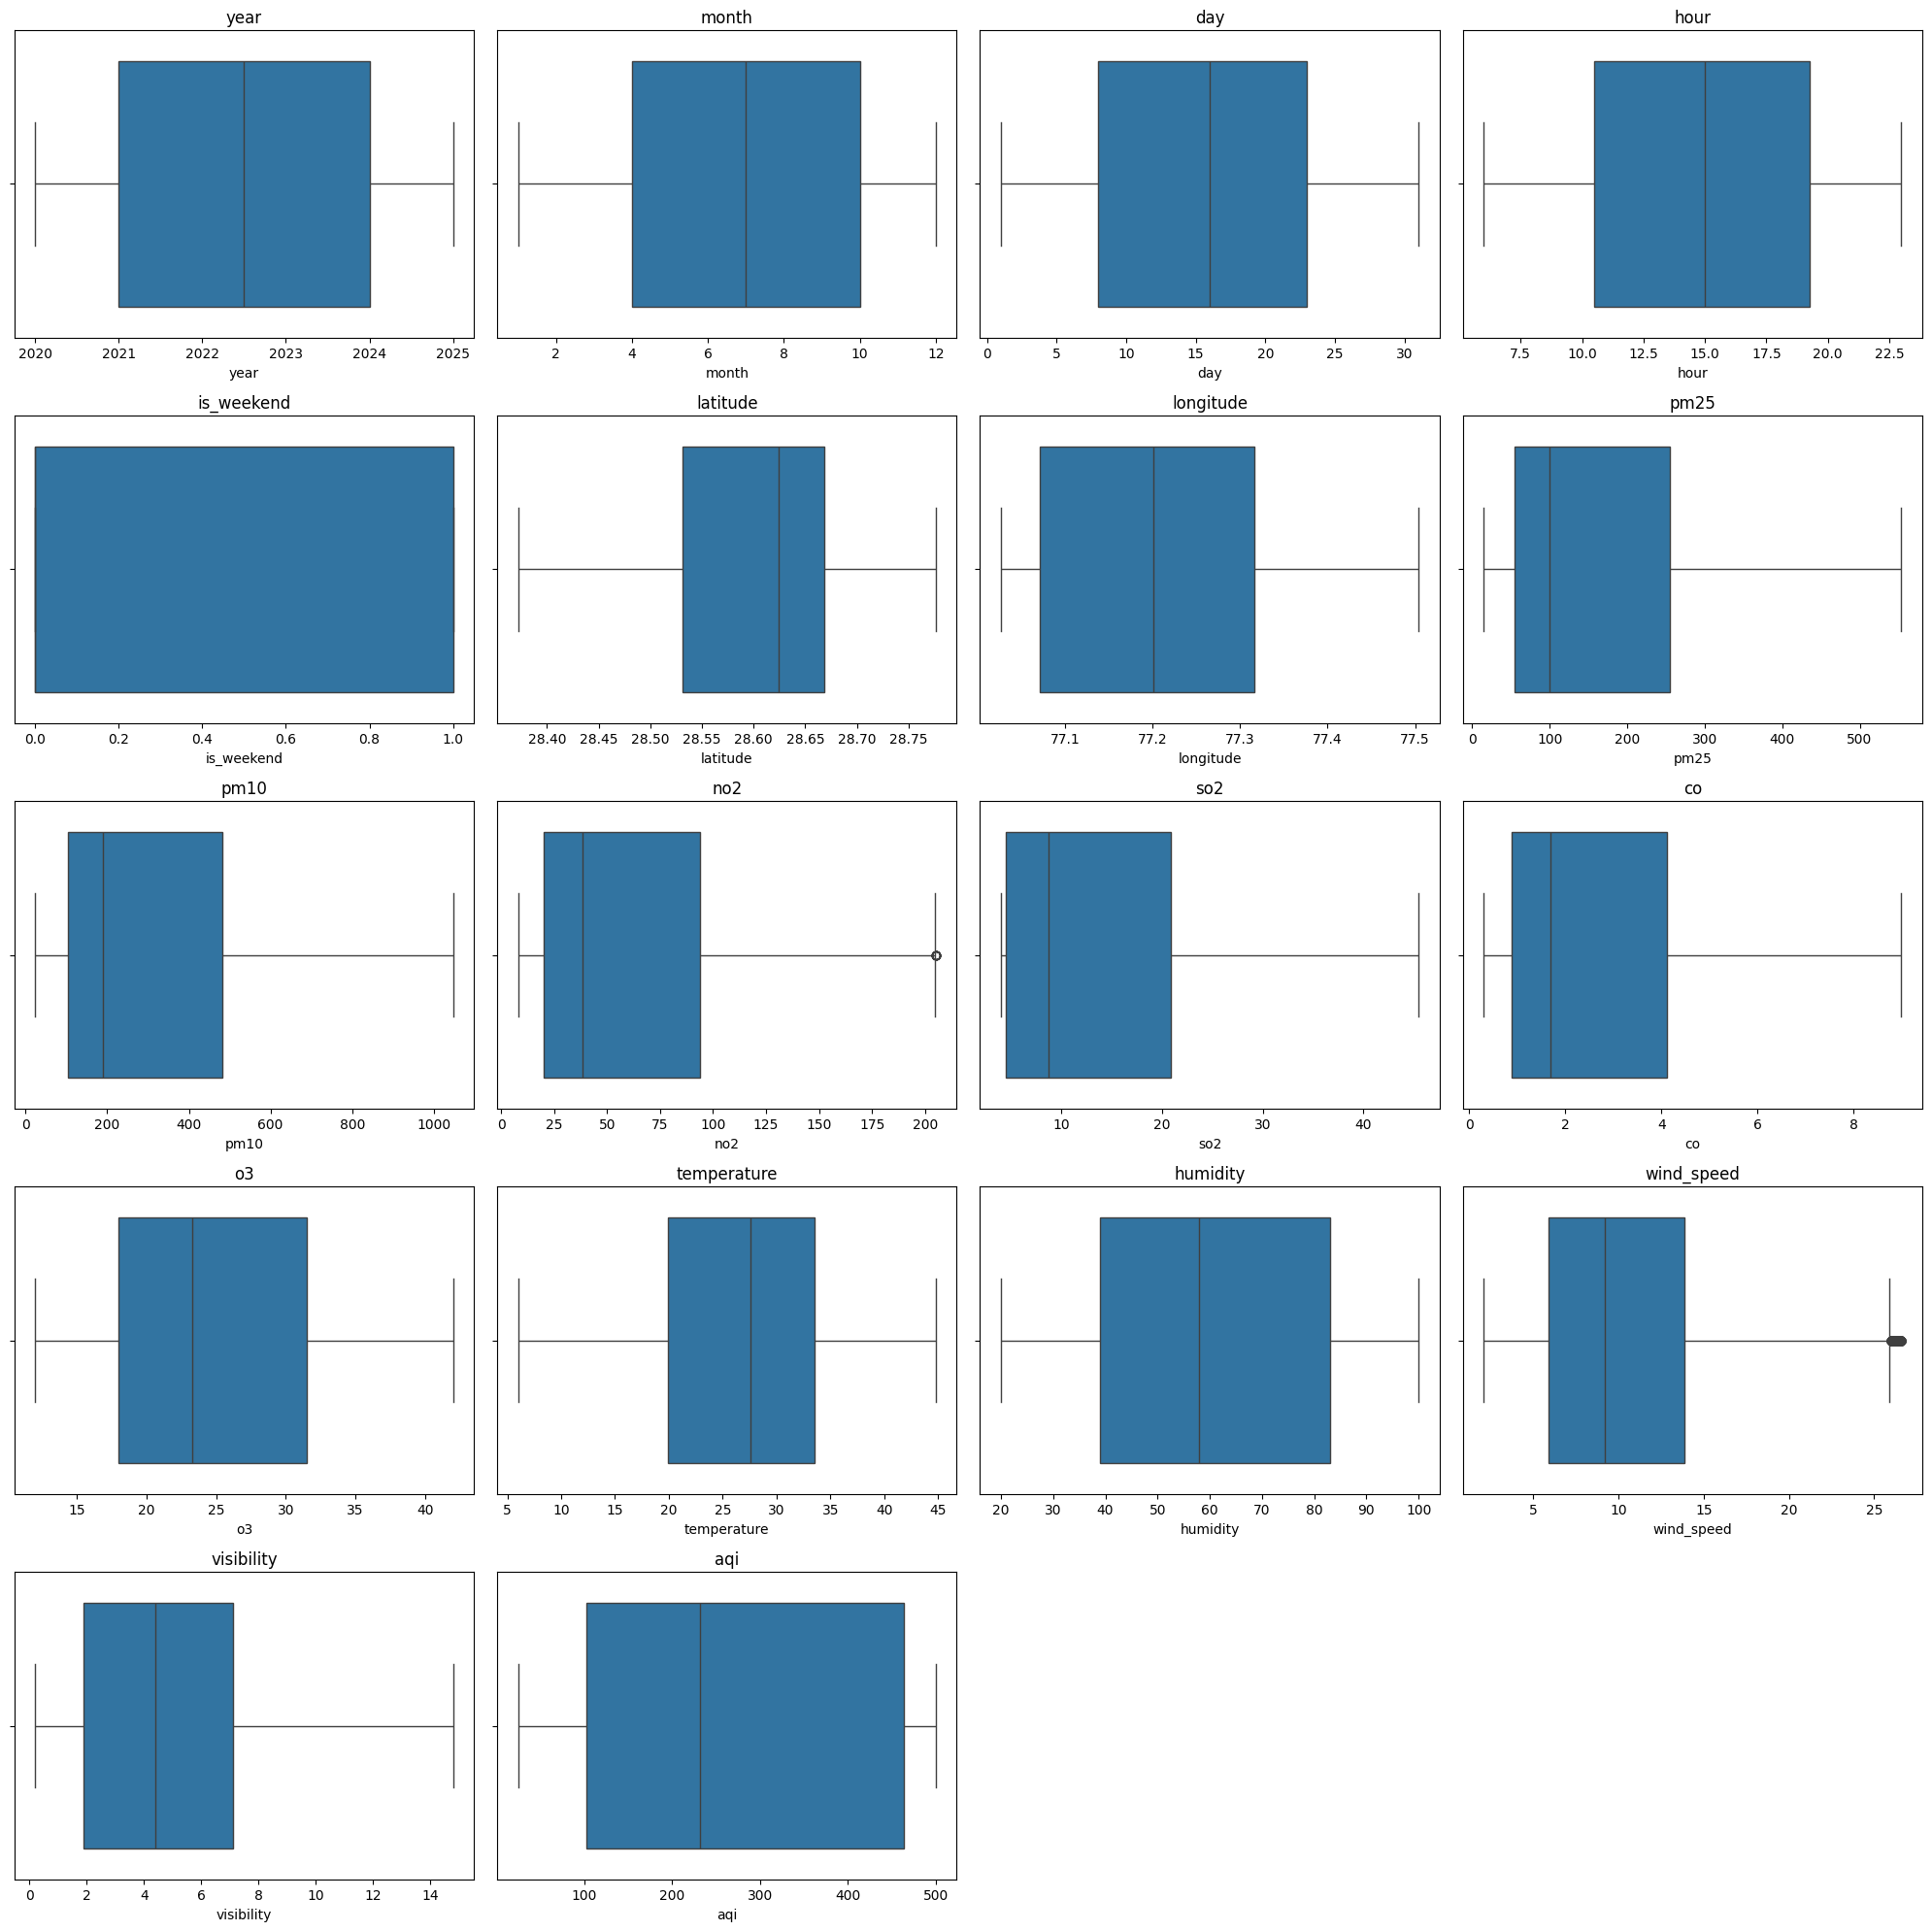

In [70]:
num_cols = len(numeric_columns)  # 20 in your case
cols_per_row = 4                  # 4 plots per row
rows = math.ceil(num_cols / cols_per_row)  # auto-calculate rows

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, 4*rows))
axes = axes.flatten()

for i, col in enumerate(numeric_columns):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Hide any extra empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


In [72]:
df.head(20)

,datetime,date,year,month,day,hour,day_of_week,is_weekend,season,city,...,no2,so2,co,o3,temperature,humidity,wind_speed,visibility,aqi,aqi_category
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,Wednesday,0,winter,Delhi,...,119.6,39.30,5.190,12.3,9.4,100,3.6,1.2,500,Severe
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,Wednesday,0,winter,Delhi,...,117.9,39.30,4.320,15.8,20.6,50,5.9,1.4,500,Severe
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,Wednesday,0,winter,Delhi,...,150.1,36.30,7.130,14.3,12.4,56,4.5,1.1,500,Severe
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,Wednesday,0,winter,Delhi,...,142.0,30.30,4.900,13.2,14.4,48,5.8,1.4,500,Severe
92,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,Thursday,0,winter,Delhi,...,134.8,39.90,7.620,15.1,10.0,98,3.3,0.5,500,Severe
93,2020-01-02 12:00:00,2020-01-02,2020,1,2,12,Thursday,0,winter,Delhi,...,104.9,24.10,4.490,15.6,17.8,62,9.7,1.2,500,Severe
94,2020-01-02 18:00:00,2020-01-02,2020,1,2,18,Thursday,0,winter,Delhi,...,136.0,21.90,5.030,28.6,14.5,59,6.7,1.1,500,Severe
95,2020-01-02 23:00:00,2020-01-02,2020,1,2,23,Thursday,0,winter,Delhi,...,106.6,30.50,4.560,16.8,13.6,60,5.0,0.9,500,Severe
184,2020-01-03 06:00:00,2020-01-03,2020,1,3,6,Friday,0,winter,Delhi,...,122.7,35.65,4.760,13.5,7.1,100,3.5,1.4,500,Severe
185,2020-01-03 12:00:00,2020-01-03,2020,1,3,12,Friday,0,winter,Delhi,...,125.1,40.80,3.750,16.0,18.5,56,9.2,0.9,500,Severe


In [74]:
lst1 = ['pm25', 'pm10', 'no2','so2', 'co', 'o3', 'wind_speed', 'visibility'] 

for i in lst1:
    LB, UB = get_iqr_bounds(df[i])
    print(f"For feature {i}")
    print(f"Lower Bound: {LB}")
    print(f"Upper Bound: {UB}")
    values = (df[i] > UB).sum()
    print(values)  ###wind speed outliers are due to sesory errors

For feature pm25
Lower Bound: -243.79999999999995
Upper Bound: 553.8
0
For feature pm10
Lower Bound: -461.55000000000007
Upper Bound: 1046.8500000000001
0
For feature no2
Lower Bound: -91.1
Upper Bound: 204.9
18
For feature so2
Lower Bound: -20.099999999999998
Upper Bound: 45.5
0
For feature co
Lower Bound: -4.005
Upper Bound: 8.995000000000001
0
For feature o3
Lower Bound: -2.25
Upper Bound: 51.75
0
For feature wind_speed
Lower Bound: -6.1
Upper Bound: 25.9
534
For feature visibility
Lower Bound: -5.899999999999999
Upper Bound: 14.899999999999999
0


In [76]:
df.shape

(201664, 25)

### Univariate Analysis

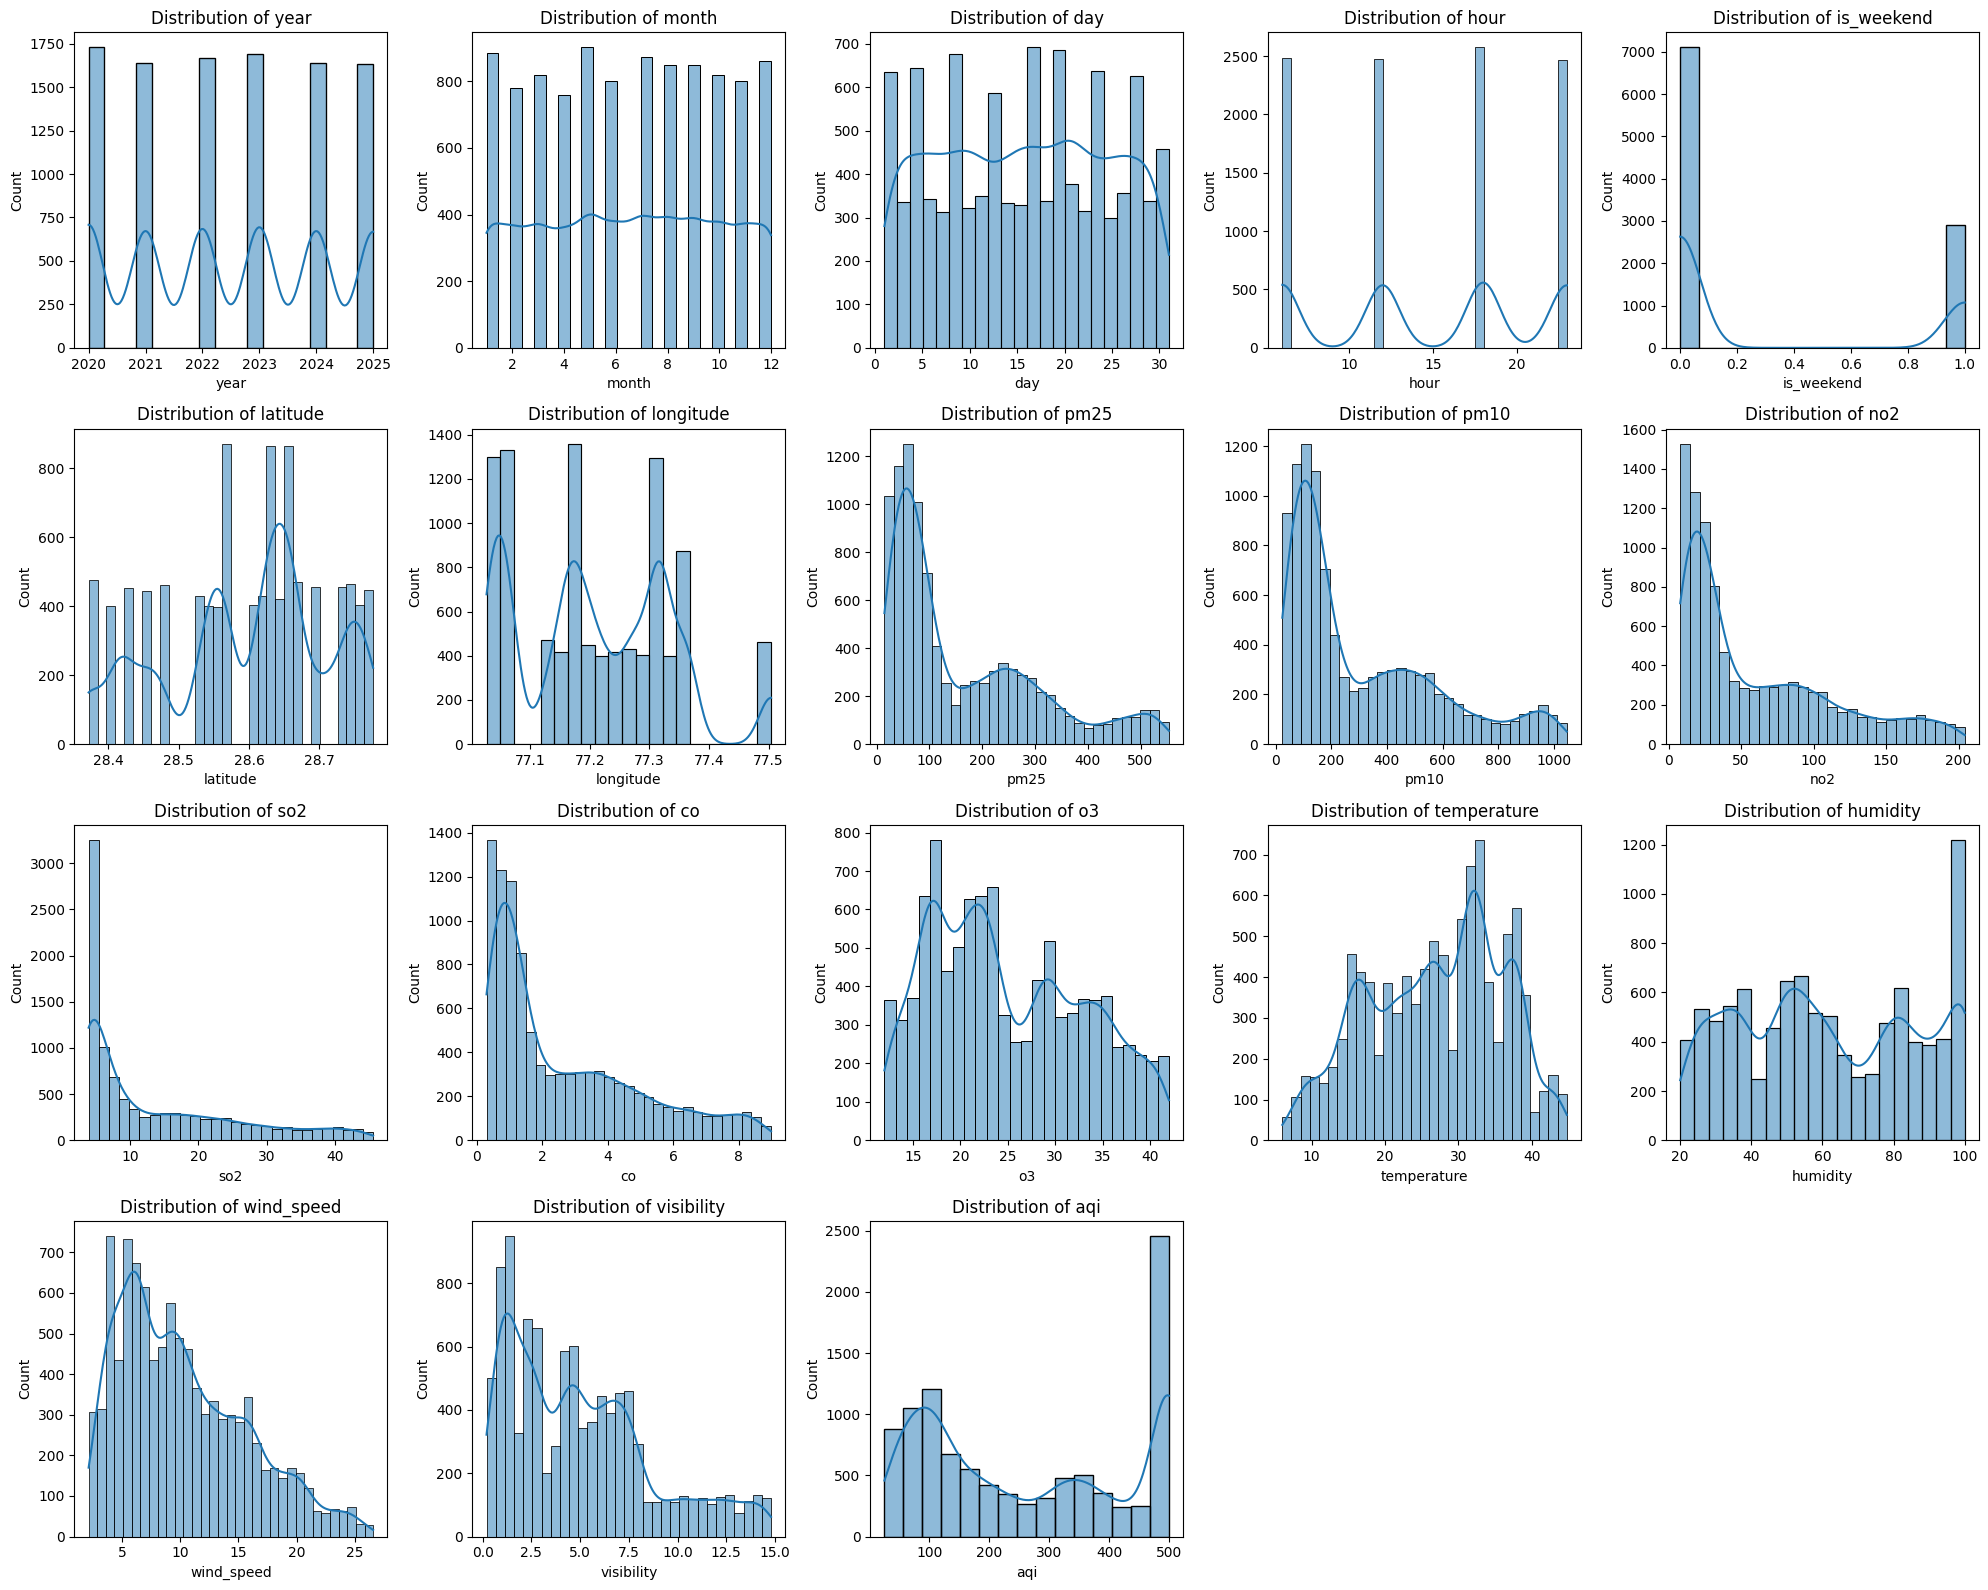

In [78]:
df_sample = df.sample(10000, random_state=42)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    sns.histplot(df_sample[col], kde=True, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)

# Hide empty subplots if numeric_columns < 20
for idx in range(len(numeric_columns), 20):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

### Bivariate analysis

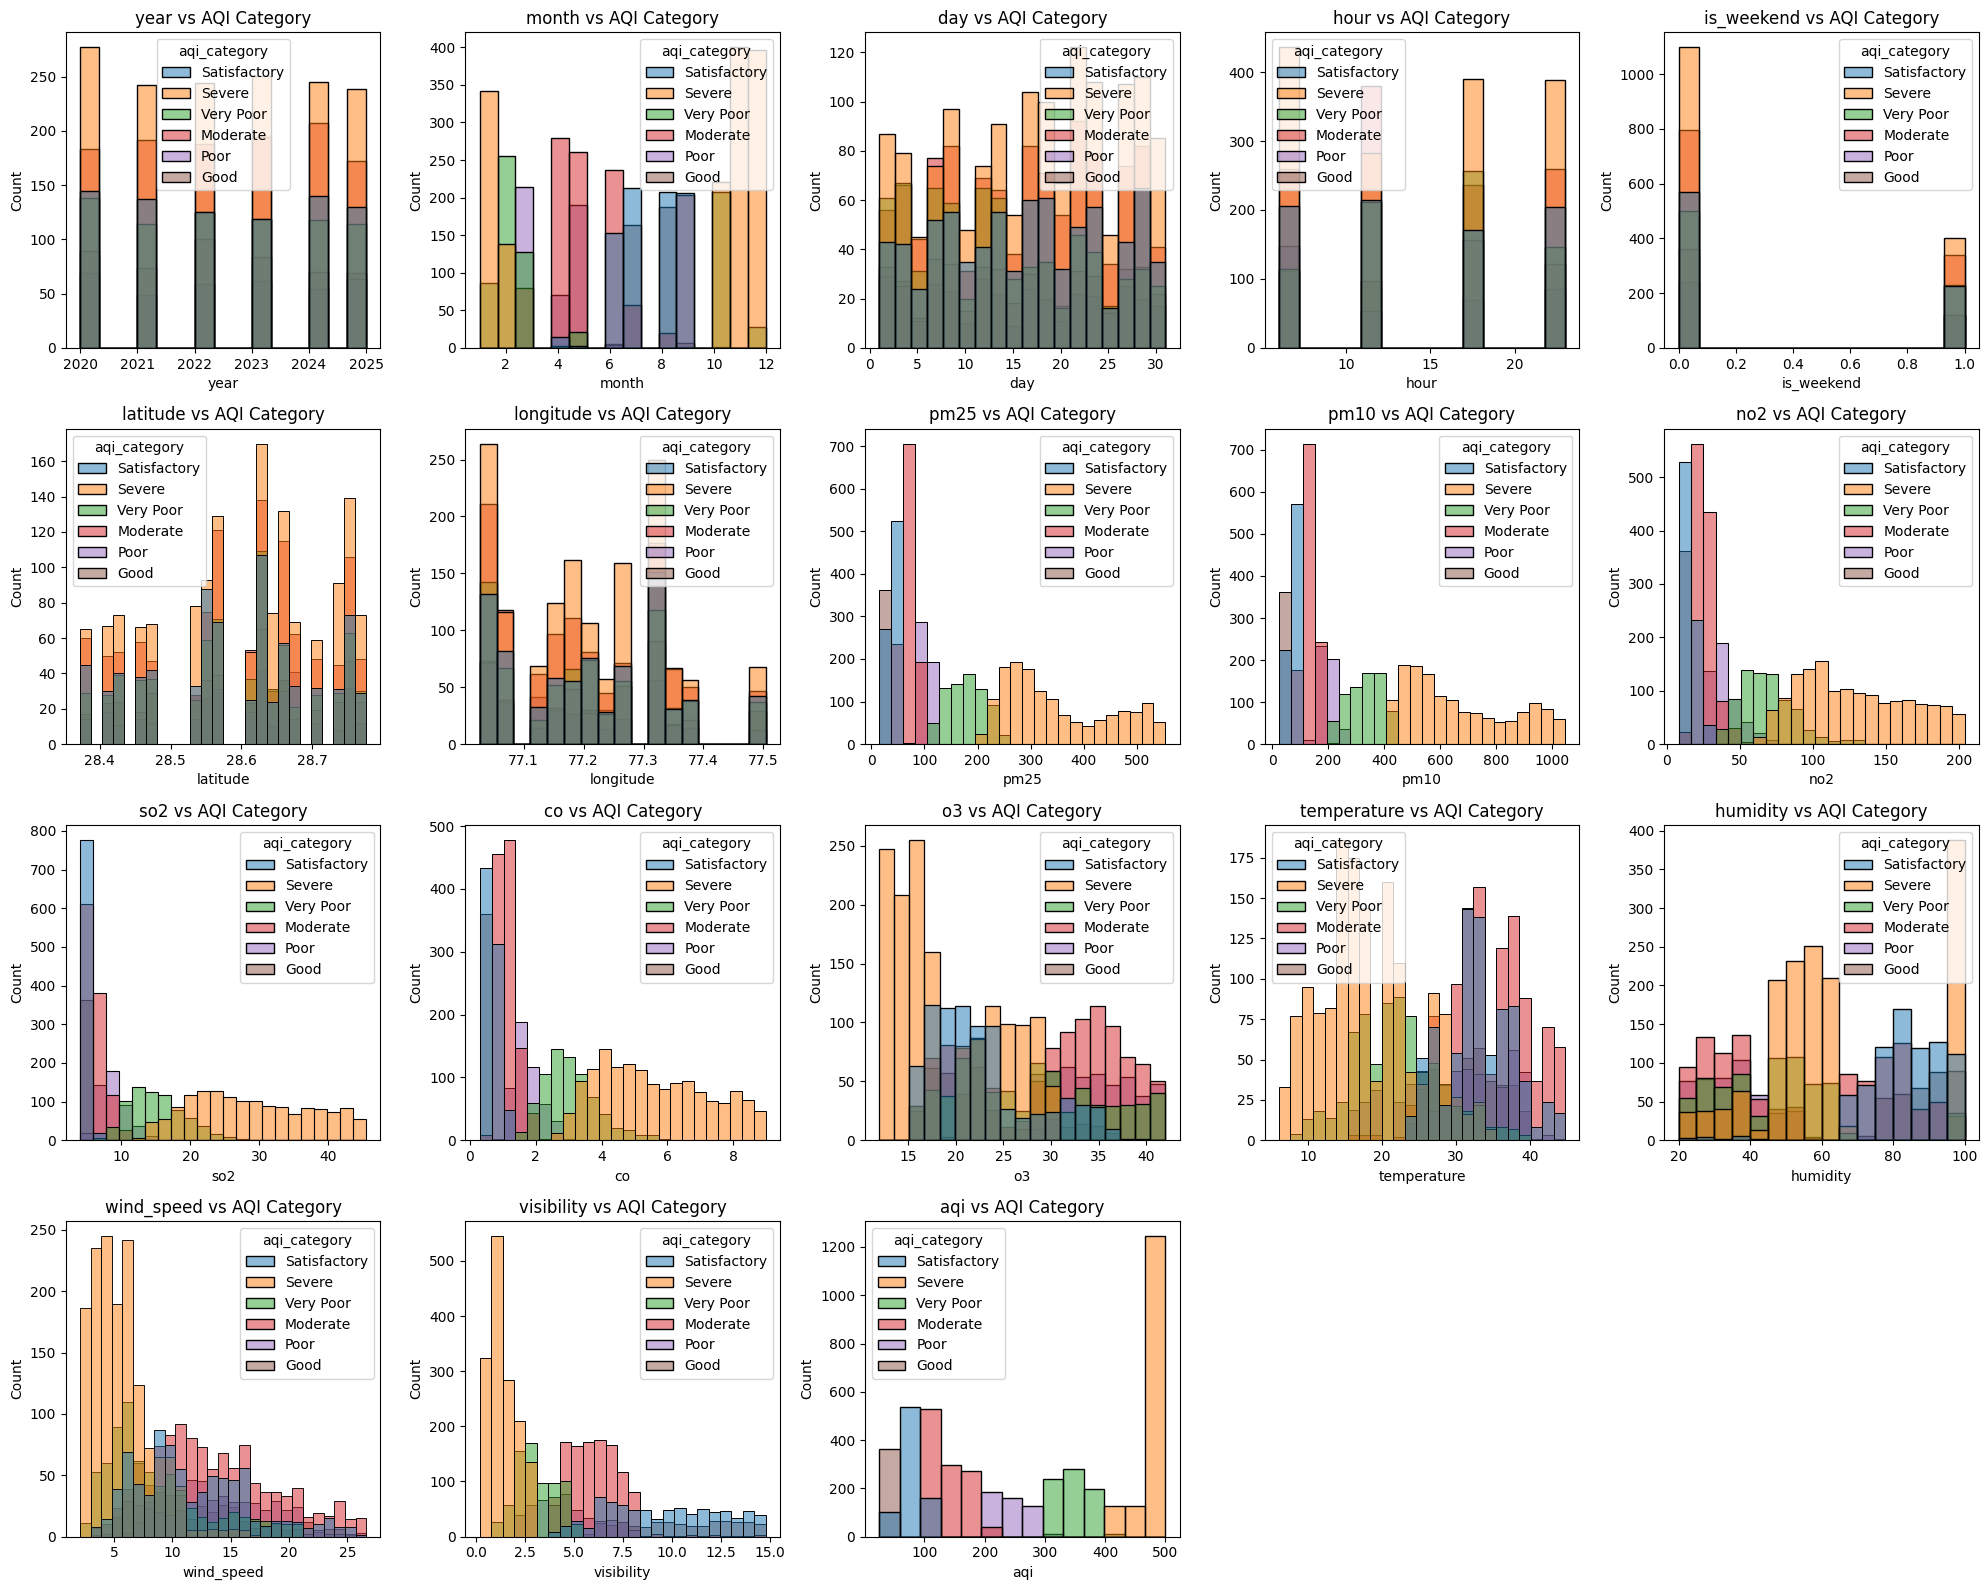

In [80]:
df_sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(numeric_columns):
    sns.histplot(data=df_sample, x=col, hue='aqi_category',
                 kde=False, ax=axes[idx], alpha=0.5)
    axes[idx].set_title(f'{col} vs AQI Category')
    axes[idx].set_xlabel(col)

for idx in range(len(numeric_columns), 20):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

In [82]:
alpha_cols = df.select_dtypes('object').columns
alpha_cols

Index(['day_of_week', 'season', 'city', 'station', 'aqi_category'], dtype='object')

### Feature Enginnering
### Encoding(Label)

In [84]:
for i in alpha_cols:
    print(df[i].unique())

['Wednesday' 'Thursday' 'Friday' 'Saturday' 'Sunday' 'Monday' 'Tuesday']
['winter' 'summer' 'monsoon' 'post_monsoon']
['Delhi' 'Faridabad' 'Ghaziabad' 'Noida' 'Gurugram']
['Anand Vihar, Delhi' 'Bawana, Delhi' 'Dwarka Sec 8, Delhi'
 'Faridabad New Town' 'Faridabad Sec 16A' 'Ghaziabad Loni'
 'Ghaziabad Vasundhara' 'Greater Noida' 'Gurugram Sec 51'
 'Gurugram Vikas Sadan' 'ITO, Delhi' 'Jahangirpuri, Delhi'
 'Mandir Marg, Delhi' 'NSIT Dwarka, Delhi' 'Noida Sec 125' 'Noida Sec 62'
 'Okhla Phase 2, Delhi' 'Punjabi Bagh, Delhi' 'RK Puram, Delhi'
 'Rohini, Delhi' 'Shadipur, Delhi' 'Siri Fort, Delhi' 'Wazirpur, Delhi']
['Severe' 'Very Poor' 'Poor' 'Moderate' 'Satisfactory' 'Good']


In [86]:
df['day_of_week'] = df['day_of_week'].map({'Monday' : 1,
                                           'Tuesday' : 2,
                                           'Wednesday' : 3,
                                           'Thursday' : 4,
                                           'Friday' : 5,
                                           'Saturday' : 6,
                                           'Sunday' : 7})
df['station'] = df['station'].map({'Anand Vihar, Delhi': 1,
                                   'Bawana, Delhi': 2,
                                   'Dwarka Sec 8, Delhi': 3,
                                   'Faridabad New Town': 4,
                                   'Faridabad Sec 16A': 5,
                                   'Ghaziabad Loni': 6,
                                   'Ghaziabad Vasundhara': 7,
                                   'Greater Noida': 8,
                                   'Gurugram Sec 51': 9,
                                   'Gurugram Vikas Sadan': 10,
                                   'ITO, Delhi': 11,
                                   'Jahangirpuri, Delhi': 12,
                                   'Mandir Marg, Delhi': 13,
                                   'NSIT Dwarka, Delhi': 14,
                                   'Noida Sec 125': 15,
                                   'Noida Sec 62': 16,
                                   'Okhla Phase 2, Delhi': 17,
                                   'Punjabi Bagh, Delhi': 18,
                                   'RK Puram, Delhi': 19,
                                   'Rohini, Delhi': 20,
                                   'Shadipur, Delhi': 21,
                                   'Siri Fort, Delhi': 22,
                                   'Wazirpur, Delhi': 23 })


### One Hot Encoding

In [87]:
nominal_columns = ['season', 'city',]

df2 = pd.get_dummies(df, columns = nominal_columns, drop_first = True, dtype= int)


In [88]:
df2.head(20)

,datetime,date,year,month,day,hour,day_of_week,is_weekend,station,latitude,...,visibility,aqi,aqi_category,season_post_monsoon,season_summer,season_winter,city_Faridabad,city_Ghaziabad,city_Gurugram,city_Noida
0,2020-01-01 06:00:00,2020-01-01,2020,1,1,6,3,0,1,28.6469,...,1.2,500,Severe,0,0,1,0,0,0,0
1,2020-01-01 12:00:00,2020-01-01,2020,1,1,12,3,0,1,28.6469,...,1.4,500,Severe,0,0,1,0,0,0,0
2,2020-01-01 18:00:00,2020-01-01,2020,1,1,18,3,0,1,28.6469,...,1.1,500,Severe,0,0,1,0,0,0,0
3,2020-01-01 23:00:00,2020-01-01,2020,1,1,23,3,0,1,28.6469,...,1.4,500,Severe,0,0,1,0,0,0,0
92,2020-01-02 06:00:00,2020-01-02,2020,1,2,6,4,0,1,28.6469,...,0.5,500,Severe,0,0,1,0,0,0,0
93,2020-01-02 12:00:00,2020-01-02,2020,1,2,12,4,0,1,28.6469,...,1.2,500,Severe,0,0,1,0,0,0,0
94,2020-01-02 18:00:00,2020-01-02,2020,1,2,18,4,0,1,28.6469,...,1.1,500,Severe,0,0,1,0,0,0,0
95,2020-01-02 23:00:00,2020-01-02,2020,1,2,23,4,0,1,28.6469,...,0.9,500,Severe,0,0,1,0,0,0,0
184,2020-01-03 06:00:00,2020-01-03,2020,1,3,6,5,0,1,28.6469,...,1.4,500,Severe,0,0,1,0,0,0,0
185,2020-01-03 12:00:00,2020-01-03,2020,1,3,12,5,0,1,28.6469,...,0.9,500,Severe,0,0,1,0,0,0,0


In [89]:
cols_to_drop = ['date','aqi_category']

df2 = df2.drop(columns=cols_to_drop)

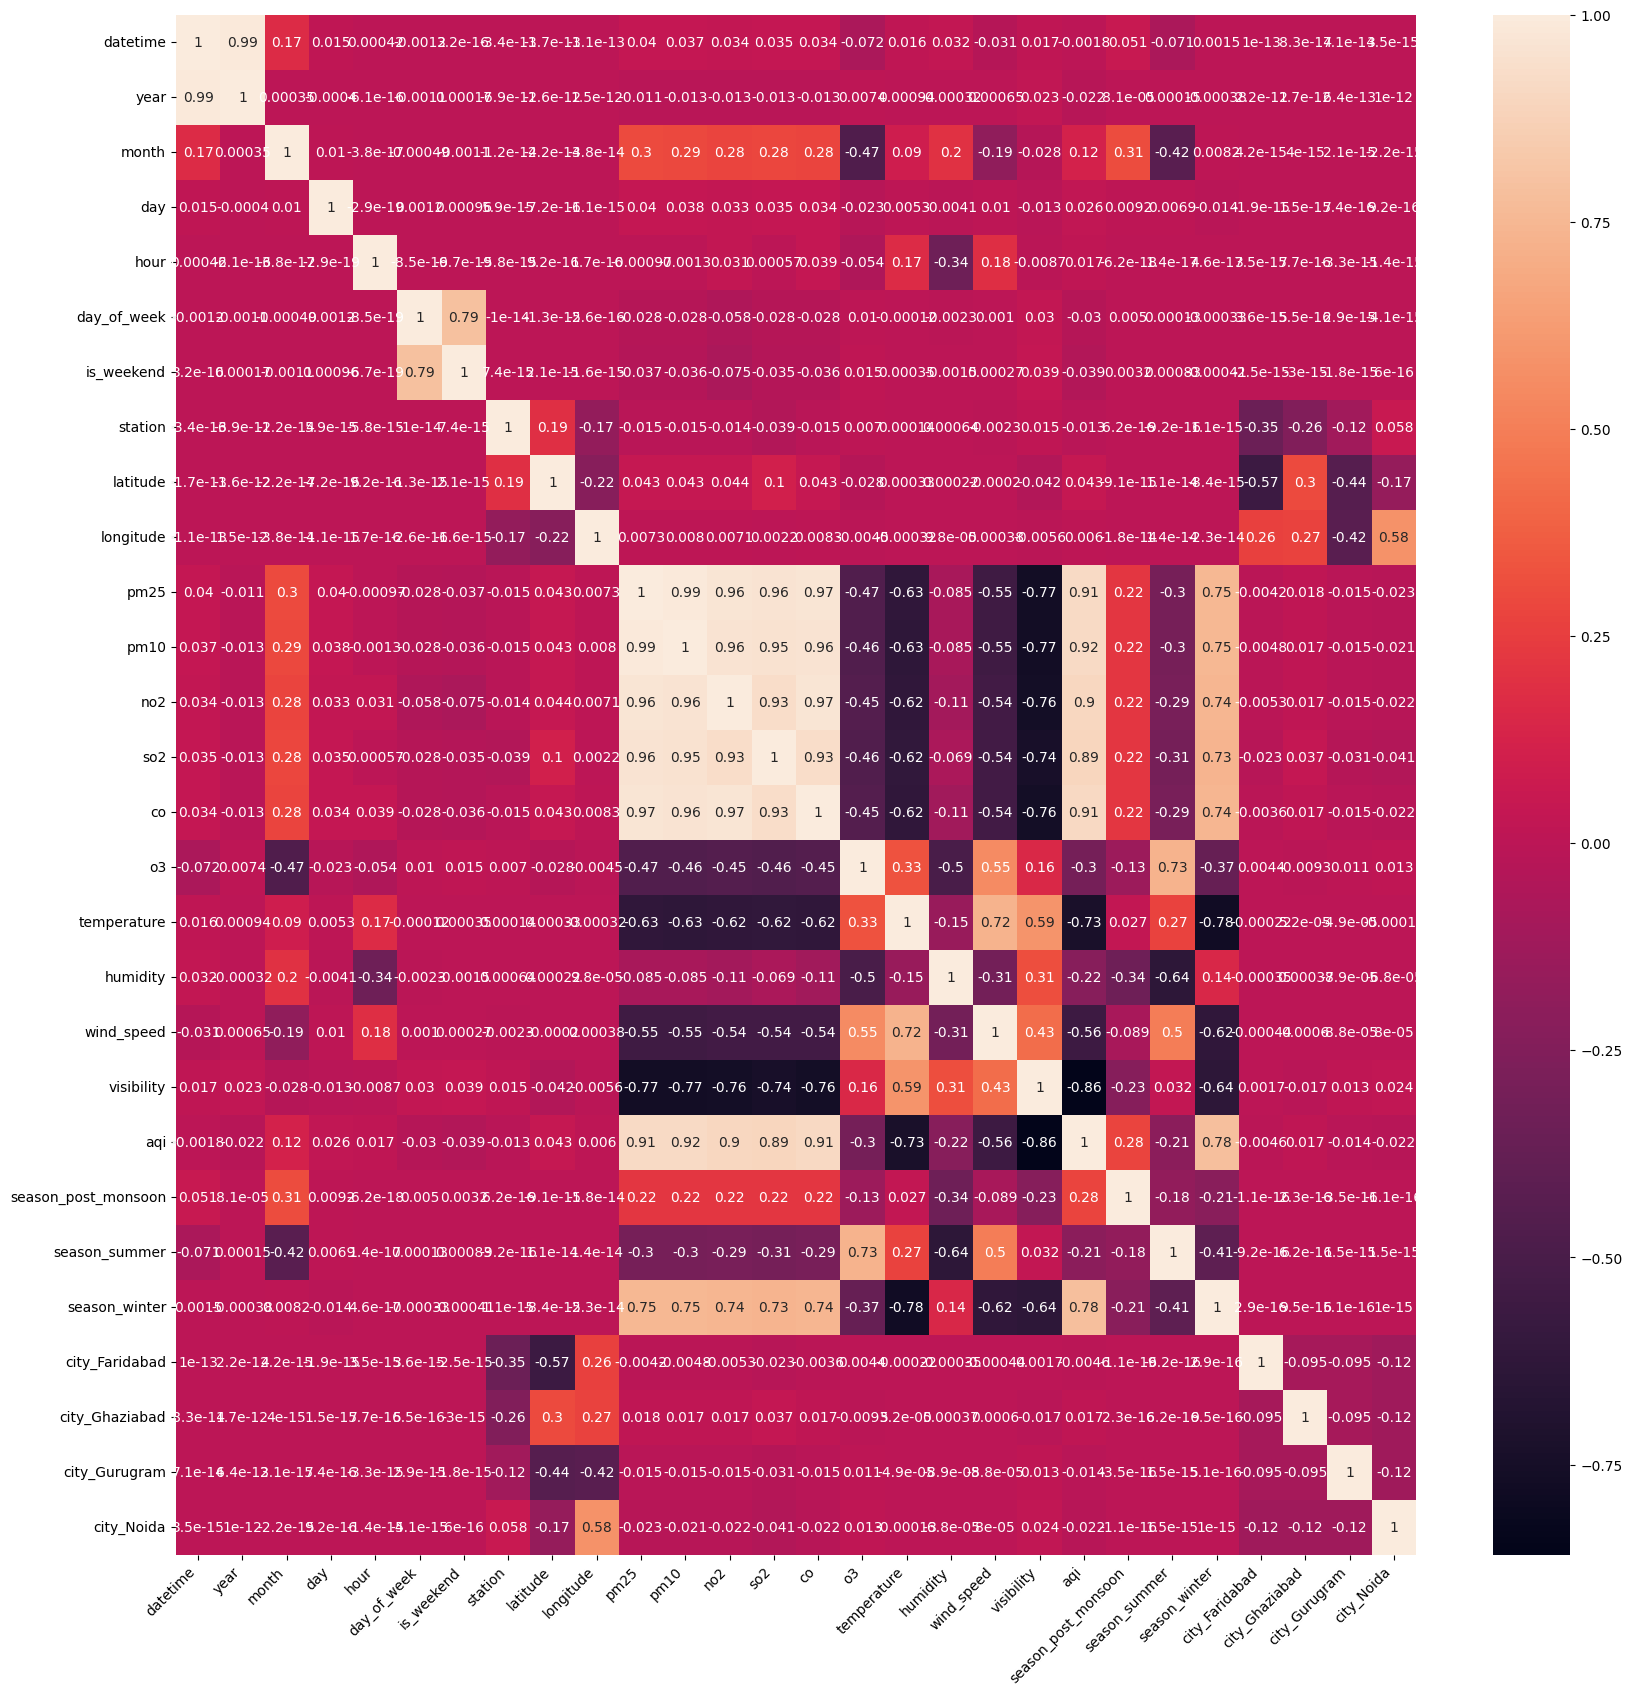

In [90]:
corr_matrix = df2.corr()
plt.figure(figsize = (20,20))
sns.heatmap(corr_matrix, annot =True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

In [91]:
df2.set_index('datetime',inplace =True)


In [92]:
df2.columns

Index(['year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'station',
       'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi',
       'season_post_monsoon', 'season_summer', 'season_winter',
       'city_Faridabad', 'city_Ghaziabad', 'city_Gurugram', 'city_Noida'],
      dtype='object')

In [93]:
lag_cols = ['pm25', 'pm10', 'no2', 'so2', 'co', 'o3','aqi']

for col in lag_cols:
    df2[f'{col}_lag1'] = df2.groupby('station')[col].shift(1)
    df2[f'{col}_lag2'] = df2.groupby('station')[col].shift(2)
    df2[f'{col}_lag3'] = df2.groupby('station')[col].shift(3)
    df2[f'{col}_lag4'] = df2.groupby('station')[col].shift(4)
    df2[f'{col}_lag5'] = df2.groupby('station')[col].shift(5)
    df2[f'{col}_lag6'] = df2.groupby('station')[col].shift(6)

df2 = df2.dropna()

df2.columns

Index(['year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'station',
       'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3',
       'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi',
       'season_post_monsoon', 'season_summer', 'season_winter',
       'city_Faridabad', 'city_Ghaziabad', 'city_Gurugram', 'city_Noida',
       'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_lag4', 'pm25_lag5',
       'pm25_lag6', 'pm10_lag1', 'pm10_lag2', 'pm10_lag3', 'pm10_lag4',
       'pm10_lag5', 'pm10_lag6', 'no2_lag1', 'no2_lag2', 'no2_lag3',
       'no2_lag4', 'no2_lag5', 'no2_lag6', 'so2_lag1', 'so2_lag2', 'so2_lag3',
       'so2_lag4', 'so2_lag5', 'so2_lag6', 'co_lag1', 'co_lag2', 'co_lag3',
       'co_lag4', 'co_lag5', 'co_lag6', 'o3_lag1', 'o3_lag2', 'o3_lag3',
       'o3_lag4', 'o3_lag5', 'o3_lag6', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3',
       'aqi_lag4', 'aqi_lag5', 'aqi_lag6'],
      dtype='object')

In [94]:
sample = df2[df2['station']==1][['aqi','aqi_lag1','aqi_lag2','aqi_lag3']].sample(10)
print(sample)

                     aqi  aqi_lag1  aqi_lag2  aqi_lag3
datetime                                              
2023-04-01 12:00:00  149     209.0     304.0     329.0
2024-09-25 18:00:00  166      87.0     144.0     108.0
2022-06-27 18:00:00  177     175.0     190.0     146.0
2022-06-11 23:00:00  158     169.0     108.0     108.0
2021-09-01 06:00:00  159      93.0     127.0      85.0
2024-11-12 18:00:00  500     500.0     500.0     500.0
2024-07-30 06:00:00   96      56.0     113.0      46.0
2022-10-17 18:00:00  500     500.0     500.0     499.0
2025-05-05 23:00:00  299     303.0     184.0     199.0
2023-07-31 06:00:00   72      37.0     104.0      49.0


In [95]:
df2['aqi_future'] = df2.groupby('station')['aqi'].shift(-1)
df2 = df2.dropna()


df2 = df2.drop(columns=['pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'aqi'])

features = ['year', 'month', 'day', 'hour', 'day_of_week','is_weekend','station',
            'temperature', 'humidity', 'wind_speed', 'visibility','pm25_lag1', 'pm25_lag2',
            'pm25_lag3', 'pm25_lag4', 'pm25_lag5','pm25_lag6', 'pm10_lag1', 'pm10_lag2',
            'pm10_lag3', 'pm10_lag4','pm10_lag5', 'pm10_lag6', 'no2_lag1', 'no2_lag2', 'no2_lag3',
            'no2_lag4', 'no2_lag5', 'no2_lag6', 'so2_lag1', 'so2_lag2', 'so2_lag3','so2_lag4',
            'so2_lag5', 'so2_lag6', 'co_lag1', 'co_lag2', 'co_lag3',
            'co_lag4', 'co_lag5', 'co_lag6', 'o3_lag1', 'o3_lag2', 'o3_lag3',
            'o3_lag4', 'o3_lag5', 'o3_lag6', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3',
            'aqi_lag4', 'aqi_lag5', 'aqi_lag6']

x = df2[features]
y = df2['aqi_future']

split_idx = int(len(df2)*0.8)
train_df = df2.iloc[:split_idx]
test_df = df2.iloc[split_idx:]


x_train = train_df.drop(columns=['aqi_future'])
y_train = train_df['aqi_future']

x_test = test_df.drop(columns=['aqi_future'])
y_test = test_df['aqi_future']


In [96]:
cols_to_scale = ['year', 'month', 'day', 'hour', 'day_of_week','is_weekend','station',
            'temperature', 'humidity', 'wind_speed', 'visibility','pm25_lag1', 'pm25_lag2',
            'pm25_lag3', 'pm25_lag4', 'pm25_lag5','pm25_lag6', 'pm10_lag1', 'pm10_lag2',
            'pm10_lag3', 'pm10_lag4','pm10_lag5', 'pm10_lag6', 'no2_lag1', 'no2_lag2', 'no2_lag3',
            'no2_lag4', 'no2_lag5', 'no2_lag6', 'so2_lag1', 'so2_lag2', 'so2_lag3','so2_lag4',
            'so2_lag5', 'so2_lag6', 'co_lag1', 'co_lag2', 'co_lag3',
            'co_lag4', 'co_lag5', 'co_lag6', 'o3_lag1', 'o3_lag2', 'o3_lag3',
            'o3_lag4', 'o3_lag5', 'o3_lag6', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3',
            'aqi_lag4', 'aqi_lag5', 'aqi_lag6']


In [97]:
scaler = StandardScaler()

x_train_scaled = x_train.copy()
x_test_scaled  = x_test.copy()

x_train_scaled[cols_to_scale] = scaler.fit_transform(x_train[cols_to_scale])
x_test_scaled[cols_to_scale]  = scaler.transform(x_test[cols_to_scale])

### Linear Regression

In [98]:
model_lr = LinearRegression()
model_lr.fit(x_train_scaled, y_train)
model_lr.score(x_test_scaled,y_test)


0.9545814073782025

In [99]:
model_lr.score(x_train_scaled, y_train)

0.9544561345929018

### Model_LR Evaluation

In [100]:
y_pred_lr = model_lr.predict(x_test_scaled)

print(f"R2 Score: {r2_score(y_test, y_pred_lr)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lr)}")
print(f"MSE: {mean_squared_error(y_test, y_pred_lr)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr))}")

R2 Score: 0.9545814073782025
MAE: 27.91202477375913
MSE: 1345.0374419424631
RMSE: 36.674752104717264


### Random forest

In [101]:
model_rf = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
model_rf.fit(x_train_scaled, y_train)
model_rf.score(x_test_scaled,y_test)

0.96788937555219

In [102]:
model_rf.score(x_train_scaled, y_train)

0.9716384972815778

### Model_RF Evaluation

In [103]:
y_pred_rf = model_rf.predict(x_test_scaled)

print(f"R2 Score: {r2_score(y_test, y_pred_rf)}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf)}")
print(f"MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf))}")

R2 Score: 0.96788937555219
MAE: 22.874651363490894
MSE: 950.9319790267917
RMSE: 30.837185004905876


### Feature Importance_RF

                feature  importance
22            pm25_lag3    0.806085
58             aqi_lag3    0.104114
10             humidity    0.062033
1                 month    0.006278
14        season_summer    0.003800
9           temperature    0.002424
21            pm25_lag2    0.002267
7              latitude    0.001217
2                   day    0.001207
3                  hour    0.001114
20            pm25_lag1    0.001093
4           day_of_week    0.001000
51              o3_lag2    0.000890
23            pm25_lag4    0.000800
44              co_lag1    0.000489
55              o3_lag6    0.000384
13  season_post_monsoon    0.000366
25            pm25_lag6    0.000335
12           visibility    0.000282
5            is_weekend    0.000239


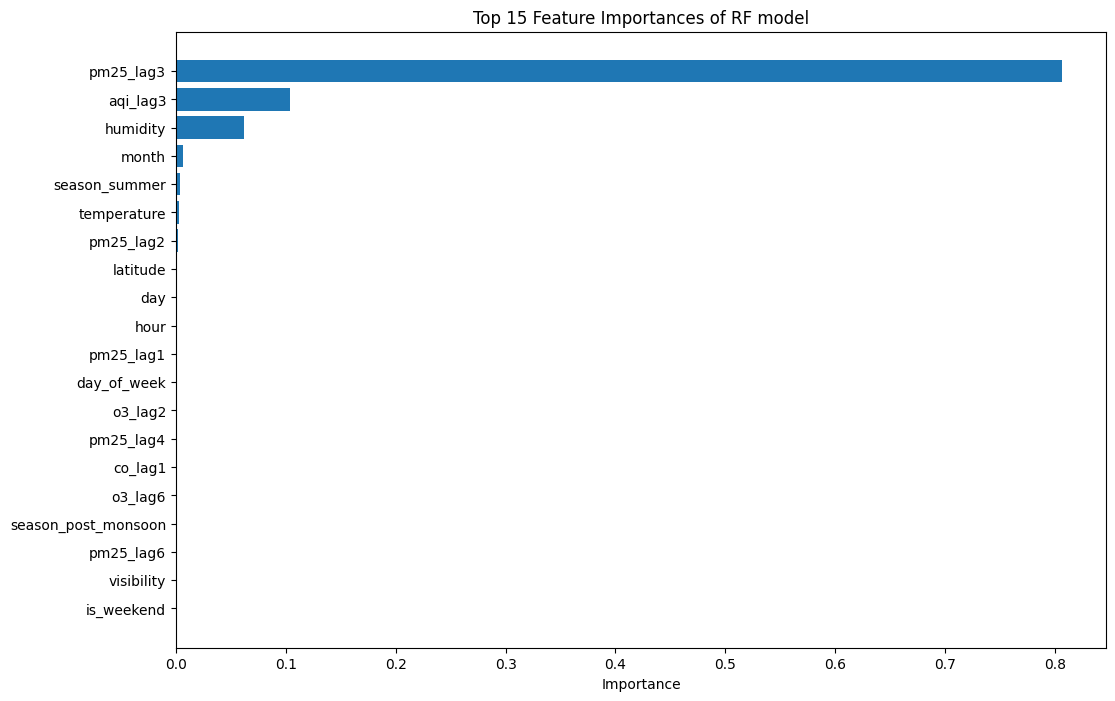

In [104]:
feature_importance_rf = pd.DataFrame({
    'feature': x_train_scaled.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_rf.head(20))

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_rf['feature'][:20], 
         feature_importance_rf['importance'][:20])
plt.title('Top 15 Feature Importances of RF model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

### XG Boost

In [105]:
model_xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

model_xgb.fit(x_train_scaled, y_train)

print("XGB Train Score:", model_xgb.score(x_train_scaled, y_train))
print("XGB Test Score:", model_xgb.score(x_test_scaled, y_test))

XGB Train Score: 0.9739049229629065
XGB Test Score: 0.9714933343488343


### Model_XGB Evaluation

In [106]:
y_pred_xgb = model_xgb.predict(x_test_scaled)
print(f"R2:   {r2_score(y_test, y_pred_xgb):.4f}")
print(f"MAE:  {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_xgb)):.4f}")

R2:   0.9715
MAE:  21.7000
RMSE: 29.0552


### Feature Importance_XGB

                feature  importance
58             aqi_lag3    0.523817
56             aqi_lag1    0.187787
22            pm25_lag3    0.148778
10             humidity    0.066161
14        season_summer    0.023802
38             so2_lag1    0.004808
1                 month    0.003771
20            pm25_lag1    0.003742
42             so2_lag5    0.003680
21            pm25_lag2    0.003618
39             so2_lag2    0.002708
57             aqi_lag2    0.002512
23            pm25_lag4    0.001903
44              co_lag1    0.001684
3                  hour    0.001623
46              co_lag3    0.001292
25            pm25_lag6    0.001188
13  season_post_monsoon    0.001178
43             so2_lag6    0.001064
41             so2_lag4    0.001004


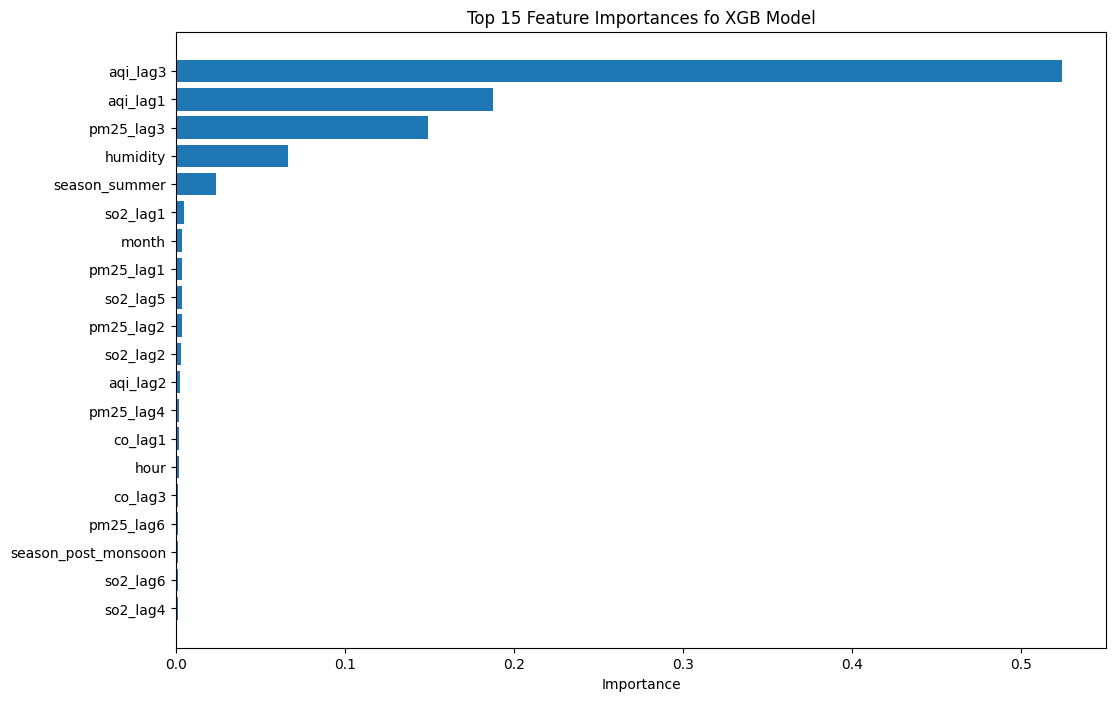

In [107]:
feature_importance_xgb = pd.DataFrame({
    'feature': x_train_scaled.columns,
    'importance': model_xgb.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_xgb.head(20))

plt.figure(figsize=(12, 8))
plt.barh(feature_importance_xgb['feature'][:20], 
         feature_importance_xgb['importance'][:20])
plt.title('Top 15 Feature Importances fo XGB Model')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.show()

### Comparison of LR, RF, XGB

In [108]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'Test Score': [model_lr.score(x_test_scaled, y_test),
                   model_rf.score(x_test_scaled, y_test),
                   model_xgb.score(x_test_scaled, y_test)]
})
print(results)

               Model  Test Score
0  Linear Regression    0.954581
1      Random Forest    0.967889
2            XGBoost    0.971493


In [109]:
best_model = model_xgb

### Model HyperParameter FineTuning

In [110]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

params = {
    'n_estimators'  : [300, 500],
    'max_depth'     : [6, 8],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 0.9],
}

tscv = TimeSeriesSplit(n_splits=3)  # reduced from 5

random_search = RandomizedSearchCV(
    estimator  = model_xgb,
    param_distributions = params,
    n_iter     = 8,       # reduced from 20
    cv         = tscv,   
    scoring    = 'r2',
    random_state = 42,
    verbose    = 1,
    n_jobs     = -1
)

random_search.fit(x_train_scaled, y_train.values)
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(x_test_scaled)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


### Best Model Evaluation

In [111]:
print(f"Test R2  : {r2_score(y_test.values, y_pred_best):.4f}")
print(f"MAE      : {mean_absolute_error(y_test.values, y_pred_best):.4f}")
print(f"RMSE     : {np.sqrt(mean_squared_error(y_test.values, y_pred_best)):.4f}")

Test R2  : 0.9720
MAE      : 21.4928
RMSE     : 28.7788


### Error Analysis

In [112]:
ypred = best_model.predict(x_test_scaled)
residuals = ypred - y_test
residuals_pct = (residuals*100)/y_test
residuals_df= pd.DataFrame({'actual':y_test,
                            'predicted':ypred,
                            'difference':residuals,
                            'differnce_pct':residuals_pct
                            })
residuals_df.head(5)

,actual,predicted,difference,differnce_pct
datetime,,,,
2022-05-27 18:00:00,181.0,198.523438,17.523438,9.681457
2022-05-27 23:00:00,148.0,164.408295,16.408295,11.086686
2022-05-28 06:00:00,102.0,141.579529,39.579529,38.803460
2022-05-28 12:00:00,156.0,193.153503,37.153503,23.816348
2022-05-28 18:00:00,194.0,152.657303,-41.342697,-21.310669


<Axes: xlabel='differnce_pct', ylabel='Count'>

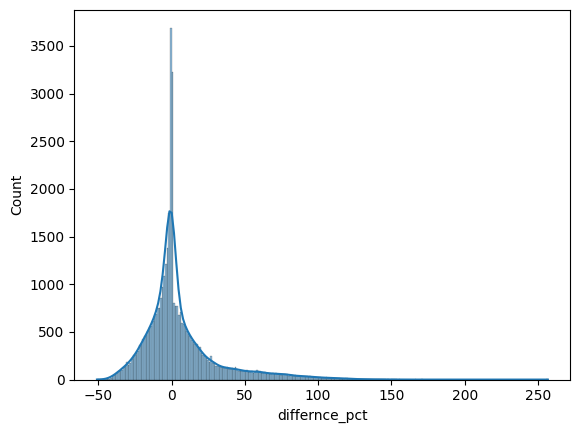

In [113]:
sns.histplot(residuals_df['differnce_pct'],kde = True)

In [114]:
extreme_error_threshold = 50
extreme_residuals_df = residuals_df[np.abs(residuals_df.differnce_pct) > extreme_error_threshold]
extreme_residuals_df.shape

(2989, 4)

In [115]:
# Check if model is underfitting or overfitting
print("Train R2:", model_xgb.score(x_train_scaled, y_train))
print("Test R2: ", model_xgb.score(x_test_scaled, y_test))
print("Train MAE:", mean_absolute_error(y_train, model_xgb.predict(x_train_scaled)))
print("Test MAE: ", mean_absolute_error(y_test, ypred))

Train R2: 0.9739049229629065
Test R2:  0.9714933343488343
Train MAE: 20.84508826164372
Test MAE:  21.492762486788717


### Saving Model

In [116]:
from joblib import dump

dump(best_model, 'artifacts/aqi_model.joblib')

scaler_with_cols = {
    'scaler':scaler,
    'cols_to_scale': cols_to_scale
}
dump(scaler_with_cols, "artifacts/scaler.joblib")


['artifacts/scaler.joblib']